# Accuracy and Precision Metrics
### Hands-on Notebook

**Learning Objectives**
1. Calculate model **Accuracy and Precision**
2. Optimize for **positive prediction reliability**

**Subtopics:** Classification Metrics · Accuracy · Precision

---
**The situation:** a camera-based inspection system on a factory assembly line labels every product "Defective" or "Good." This notebook builds, from raw predictions, the two numbers most commonly used to judge how good that labeling really is.


## 0. Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression

plt.rcParams['figure.figsize'] = (7, 4.5)
np.random.seed(42)


## 1. From predictions to a confusion matrix

For each inspected item we have two labels: what actually was true, and what the model predicted. Comparing them for every item gives four possible outcomes:

- **True Positive (TP)** — predicted Defective, actually Defective
- **True Negative (TN)** — predicted Good, actually Good
- **False Positive (FP)** — predicted Defective, actually Good (a false alarm)
- **False Negative (FN)** — predicted Good, actually Defective (a miss)

Let's build the exact 20-item example from the slides.


In [ ]:
demo = pd.DataFrame({
    "item": range(1, 21),
    "actual":    [1]*6 + [1]*2 + [0]*9 + [0]*3,   # 1 = Defective, 0 = Good  # Actual Y
    "predicted": [1]*6 + [0]*2 + [0]*9 + [1]*3,  # TP = 6, FN = 2, TN = 9, FP =3  # Predicted Y
})
demo


,item,actual,predicted
0,1,1,1
1,2,1,1
2,3,1,1
3,4,1,1
4,5,1,1
5,6,1,1
6,7,1,0
7,8,1,0
8,9,0,0
9,10,0,0


TP=6  FN=2  FP=3  TN=9


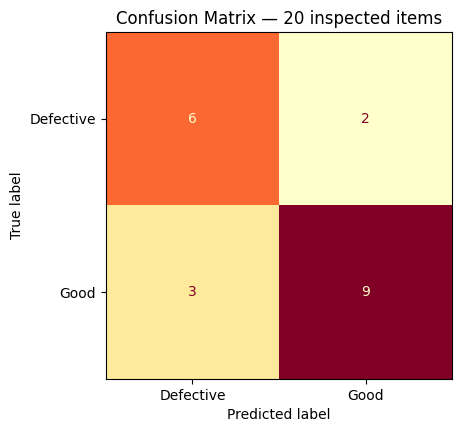

In [ ]:
tp, fn, fp, tn = confusion_matrix(demo["actual"], demo["predicted"], labels=[1, 0]).ravel()
print(f"TP={tp}  FN={fn}  FP={fp}  TN={tn}")

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(demo["actual"], demo["predicted"], labels=[1, 0]),
    display_labels=["Defective", "Good"]
)
disp.plot(cmap="YlOrRd", colorbar=False)
plt.title("Confusion Matrix — 20 inspected items")
plt.show()


**Checkpoint:** this should give TP=6, TN=9, FP=3, FN=2 — matching the slide's worked example.


## 2. Accuracy — "how often was the model right overall?"

$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

The numerator counts every correct prediction, of either class. The denominator is every item in the batch.


In [ ]:
accuracy_manual = (tp + tn) / (tp + tn + fp + fn)
print(f"Accuracy = ({tp}+{tn}) / {tp+tn+fp+fn} = {accuracy_manual:.3f}")

acc_sklearn = accuracy_score(demo["actual"], demo["predicted"])
print(f"Accuracy (sklearn): {acc_sklearn:.3f}")
assert np.isclose(accuracy_manual, acc_sklearn)
print("Manual calculation matches sklearn ✔")


Accuracy = (6+9) / 20 = 0.750
Accuracy (sklearn): 0.750
Manual calculation matches sklearn ✔


## 3. Why accuracy alone can be misleading

Defects are rare in a well-run factory. Let's simulate 500 items where only 15 are genuinely defective, and an inspection system that flags 40 items as defective — catching 12 real defects but also wrongly flagging 28 good items.


In [ ]:
rare_defect_actual = np.array([1]*15 + [0]*485)  # 1 = actually Defective, 0 = Actually Good
rare_defect_predicted = np.array(
    [1]*12 + [0]*3 +        # of the 15 real defects: 12 caught (TP), 3 missed (FN)
    [1]*28 + [0]*457        # of the 485 good items: 28 wrongly flagged [FP], 457 [TN] correctly passed
)

acc_imbalanced = accuracy_score(rare_defect_actual, rare_defect_predicted)
print(f"Accuracy on the 500-item batch: {acc_imbalanced:.3f}")


Accuracy on the 500-item batch: 0.938


93.8% accuracy looks excellent at a glance. But look specifically at what happens to the items that got flagged — that's exactly what Precision measures, and it tells a very different story.


## 4. Precision — "of everything flagged Defective, how much really was?"

$$Precision = \frac{TP}{TP + FP}$$

The denominator here is every *positive* prediction the model made — correct or not. TN and FN never appear in this formula; Precision only judges the items the model actually called "Defective."


In [ ]:
precision_manual = tp / (tp + fp)
print(f"Precision = {tp} / ({tp}+{fp}) = {precision_manual:.3f}")

prec_sklearn = precision_score(demo["actual"], demo["predicted"])
print(f"Precision (sklearn): {prec_sklearn:.3f}")
assert np.isclose(precision_manual, prec_sklearn)
print("Manual calculation matches sklearn ✔")


Precision = 6 / (6+3) = 0.667
Precision (sklearn): 0.667
Manual calculation matches sklearn ✔


### Precision on the 500-item batch

Now let's compute Precision for the same rare-defect scenario from Section 3, to see what it reveals that Accuracy didn't.


In [ ]:
prec_imbalanced = precision_score(rare_defect_actual, rare_defect_predicted)
print(f"Accuracy:  {acc_imbalanced:.3f}")
print(f"Precision: {prec_imbalanced:.3f}")


Accuracy:  0.938
Precision: 0.300


**The gap:** 93.8% accuracy, but only 30% precision. Out of every 10 items this system flags "Defective," only about 3 genuinely are — the rest are good products pulled off the line by mistake. Both numbers come from the exact same four counts; they simply ask different questions of those counts.


## 5. Optimizing for positive prediction reliability — the decision threshold

Most classifiers output a **score** for how likely the positive class is — a probability between 0 and 1 — rather than a direct label. A **decision threshold** turns that score into a final label: score at or above the threshold → positive, below it → negative. Raising the threshold makes the model pickier about committing to a positive call, which is a direct way to raise Precision.

To see this on real data rather than a made-up example, we'll switch to scikit-learn's built-in **breast cancer diagnostic dataset** — 569 real patient scans, each with 30 measured features (cell radius, texture, smoothness, and so on), labeled malignant or benign. It's a genuine, widely-used benchmark bundled with scikit-learn, so no internet download or synthetic data generation is needed. We'll treat "malignant" as our positive class — the case you most need to catch, just like "Defective" in the inspection line — so the same accuracy/precision logic applies directly.


In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

cancer = load_breast_cancer()
print(cancer.target_names)   # ['malignant' 'benign'] — sklearn encodes malignant=0, benign=1

# Flip so 1 = malignant (our positive class, the case we most need to catch)
X = cancer.data
y = (cancer.target == 0).astype(int)  #astype converts True or False into 1 or 0

print(f"Total cases: {len(y)}   Malignant (positive): {y.sum()}   Benign (negative): {(1 - y).sum()}")


['malignant' 'benign']
Total cases: 569   Malignant (positive): 212   Benign (negative): 357


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = LogisticRegression(max_iter=5000)
clf.fit(X_train_scaled, y_train)

predicted_scores = clf.predict_proba(X_test_scaled)[:, 1]
# Funciton gives an array of P(0) and P(1), we are interested in probability of "malignant" for each test case, so second column ([1]) with all rows (:)

print(f"Test set size: {len(y_test)}   Malignant in test set: {y_test.sum()}")
#print(predicted_scores)

Test set size: 171   Malignant in test set: 64


In [ ]:
thresholds = [0.3, 0.5, 0.7, 0.9]
results = []

for t in thresholds:
    labels_at_t = (predicted_scores >= t).astype(int)
    acc_t = accuracy_score(y_test, labels_at_t)
    prec_t = precision_score(y_test, labels_at_t, zero_division=0)
    n_flagged = labels_at_t.sum()
    results.append({"threshold": t, "accuracy": acc_t, "precision": prec_t, "n_flagged_malignant": n_flagged})

results_df = pd.DataFrame(results)
results_df


,threshold,accuracy,precision,n_flagged_malignant
0,0.3,0.982456,0.984127,63
1,0.5,0.970760,0.983607,61
2,0.7,0.970760,1.000000,59
3,0.9,0.923977,1.000000,51


Notice Precision generally rises as the threshold increases, while the number of cases flagged "malignant" shrinks — the model is only committing to "malignant" when it's more confident.


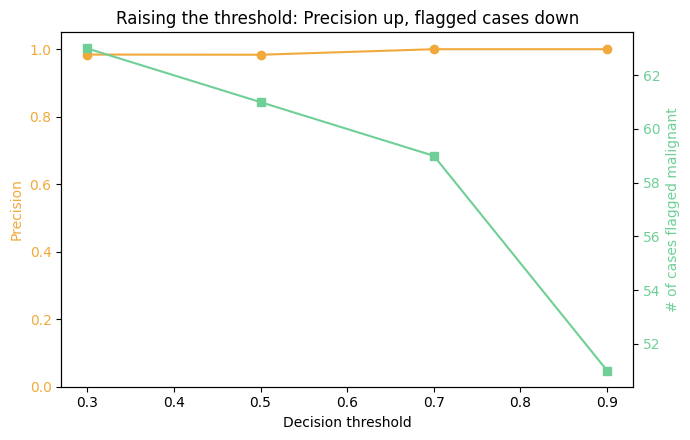

In [ ]:
fig, ax1 = plt.subplots()
ax1.plot(results_df["threshold"], results_df["precision"], marker="o", color="#F2A93B", label="Precision")
ax1.set_xlabel("Decision threshold")
ax1.set_ylabel("Precision", color="#F2A93B")
ax1.tick_params(axis="y", labelcolor="#F2A93B")
ax1.set_ylim(0, 1.05)

ax2 = ax1.twinx()
ax2.plot(results_df["threshold"], results_df["n_flagged_malignant"], marker="s", color="#6FCF97", label="# flagged malignant")
ax2.set_ylabel("# of cases flagged malignant", color="#6FCF97")
ax2.tick_params(axis="y", labelcolor="#6FCF97")

plt.title("Raising the threshold: Precision up, flagged cases down")
plt.tight_layout()
plt.show()


The cost of this optimization: some genuinely malignant cases whose score falls below the new, higher threshold now get classified as benign. Precision improves, but the model catches fewer real positive cases overall — a trade-off worth keeping in mind whenever you tune a threshold. The same logic applies back on the assembly line: a stricter "Defective" threshold means fewer false alarms, but some real defects will start slipping through as "Good."


## 6. Exercises

Work through these before checking the solutions.


### Exercise 1 — Compute both metrics by hand
Given TP=8, TN=40, FP=12, FN=5, compute Accuracy and Precision by hand, then verify using the formulas above.


In [ ]:
# TODO: compute manually
tp_ex, tn_ex, fp_ex, fn_ex = 8, 40, 12, 5


<details><summary>Show solution</summary>

```python
acc_ex = (tp_ex + tn_ex) / (tp_ex + tn_ex + fp_ex + fn_ex)
prec_ex = tp_ex / (tp_ex + fp_ex)
print(acc_ex, prec_ex)   # Accuracy ≈ 0.738, Precision = 0.40
```
</details>


### Exercise 2 — Diagnose a model from its metrics
An inspection model reports 88% accuracy and 41% precision, and the positive class (Defective) makes up about 8% of the items on the line. Without seeing the raw confusion matrix, what does this combination suggest about the model's false positives?


<details><summary>Show solution</summary>

High accuracy alongside low precision on a rare positive class strongly suggests the model is generating many false positives relative to its true positives — most of its "Defective" calls are wrong, even though it stays correct often enough on the much larger "Good" class to keep accuracy looking high. This is the same shape as the 500-item batch scenario above.
</details>


### Exercise 3 — Find a threshold that hits a precision target
Using `clf`, `predicted_scores`, and `y_test` from Section 5, find the lowest threshold that achieves **Precision ≥ 0.98** on the breast cancer test set. How many cases get flagged "malignant" at that threshold, and how does that compare to the 0.5-threshold count?


In [ ]:
# TODO: sweep thresholds from 0.1 to 0.99 and find the first one with precision >= 0.98



<details><summary>Show solution</summary>

```python
for t in np.arange(0.1, 1.0, 0.01):
    labels_t = (predicted_scores >= t).astype(int)
    if labels_t.sum() == 0:
        continue
    p = precision_score(y_test, labels_t, zero_division=0)
    if p >= 0.98:
        print(f"threshold={t:.2f}  precision={p:.3f}  n_flagged={labels_t.sum()}")
        break
```
The exact threshold depends on the train/test split above, but the pattern holds: reaching very high precision means accepting noticeably fewer positive predictions than at the default 0.5 threshold.
</details>


## 7. Recap

- **Accuracy** = (TP+TN) / total — how often the model was right, across both classes.
- **Precision** = TP / (TP+FP) — how trustworthy a positive ("Defective") prediction is, looking only at the positive predictions themselves.
- The two metrics are built from the same four counts but ask different questions — a model can have high accuracy and low precision at the same time, especially when the positive class is rare.
- Raising the decision threshold is a direct way to **optimize for positive prediction reliability**: the model commits to fewer positive labels, but each one is backed by more confidence — at the cost of missing some true positives.
